# FigSupplementary.ipynb

## Introduction
This notebook focuses on plotting supplementary figures.

In [1]:
# This notebook generates supplementary figures (Fig S1, Fig S2, etc.) for the project.
# The code uses various statistical tests and plots to visualize data distributions
# and relationships (e.g., Mann-Whitney U, Levene, Kruskal-Wallis, violin plots).

from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail, get_significance_stars
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy.stats import mannwhitneyu, levene, kruskal
from matplotlib.colors import ListedColormap
import feather
import cv2
import matplotlib.lines as mlines
import numpy.ma as ma
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import csv
import itertools

set_mpl_defaults()

In [2]:
# Define run ID, experiment ID, and niche raster size.
# These settings will be used to initialize the PlotUtlis class.
run_id = '144fa175d5d1428cb9b434cd1a0024f8'
exp_id = '625518819310735286'
niche_rst_size = 100

In [3]:
# Instantiate PlotUtlis with the specified run/experiment IDs.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

In [4]:
# Create a folder for supplementary figures if it does not already exist.
create_folder(PU.plot_path_suppl)

### Fig S1

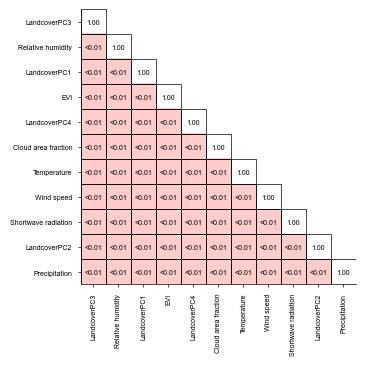

In [5]:
# This cell computes the p-values using Mann-Whitney U for every pair of environmental factors.
# We then visualize whether p-values are below a certain threshold using a heatmap.

df_attention_order = PU.df_attention.copy()
df_attention_order.columns = convert_to_env_list_detail(df_attention_order.columns)
df_attention_order = df_attention_order.sort_values(by = 'LandcoverPC1', ascending = True)
factor_order = df_attention_order.mean().sort_values(ascending = False).index
df_attention_order = df_attention_order[factor_order]
sorted_env_factors = df_attention_order.columns

p_value_matrix_sorted = pd.DataFrame(np.ones((len(sorted_env_factors), len(sorted_env_factors))), 
                                     index=sorted_env_factors, columns=sorted_env_factors)

for i, factor1 in enumerate(sorted_env_factors):
    for j, factor2 in enumerate(sorted_env_factors):
        if i == j:
            p_value_matrix_sorted.loc[factor1, factor2] = 1.0
        else:
            _, p_value = mannwhitneyu(df_attention_order[factor1], df_attention_order[factor2], alternative='two-sided')
            p_value_matrix_sorted.loc[factor1, factor2] = p_value
            p_value_matrix_sorted.loc[factor2, factor1] = p_value 

p_value_array = p_value_matrix_sorted.to_numpy()
threshold = 0.05
custom_cmap = ListedColormap(["red", "white"])

color_mask = np.where(p_value_array < threshold, 0, 1)
upper_triangle_mask = np.triu(np.ones_like(p_value_array, dtype=bool), k=1)
color_mask = np.where(upper_triangle_mask, np.nan, color_mask)

fig, ax = plt.subplots(figsize=mm2inch(90, 90), constrained_layout = True)
ax.imshow(color_mask, cmap=custom_cmap, interpolation='nearest', alpha=0.2)
ax.set_xticks(np.arange(len(sorted_env_factors)))
ax.set_yticks(np.arange(len(sorted_env_factors)))
ax.set_xticklabels(sorted_env_factors, rotation=90)
ax.set_yticklabels(sorted_env_factors)

# Draw rectangles to visually separate each cell.
for i in range(len(sorted_env_factors)):
    for j in range(len(sorted_env_factors)):
        if i >= j:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

# Annotate p-values in each applicable cell.
for i in range(len(sorted_env_factors)):
    for j in range(len(sorted_env_factors)):
        if i >= j:
            p_val = p_value_matrix_sorted.iloc[i, j]
            if round(p_val, 2) < 0.01:
                text = "<0.01"
            else:
                text = f"{round(p_val, 2):.2f}"
            ax.text(j, i, text, ha='center', va='center', color='black', fontsize=5,)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plot_output = os.path.join(PU.plot_path_suppl, 'FigS1_median.pdf')
plt.savefig(plot_output, transparent = True, dpi = 500)
plt.show()

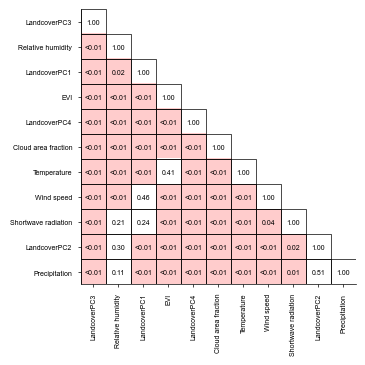

In [6]:
# This cell computes the p-values using Levene's test for every pair of environmental factors.
# Similar to the previous cell, it visualizes which p-values are below the threshold.

p_value_matrix_sorted = pd.DataFrame(np.ones((len(sorted_env_factors), len(sorted_env_factors))), 
                                     index=sorted_env_factors, columns=sorted_env_factors)

for i, factor1 in enumerate(sorted_env_factors):
    for j, factor2 in enumerate(sorted_env_factors):
        if i == j:
            p_value_matrix_sorted.loc[factor1, factor2] = 1.0
        else:
            _, p_value = levene(df_attention_order[factor1], df_attention_order[factor2])
            p_value_matrix_sorted.loc[factor1, factor2] = p_value
            p_value_matrix_sorted.loc[factor2, factor1] = p_value

p_value_array = p_value_matrix_sorted.to_numpy()
threshold = 0.05
custom_cmap = ListedColormap(["red", "white"])

color_mask = np.where(p_value_array < threshold, 0, 1)
upper_triangle_mask = np.triu(np.ones_like(p_value_array, dtype=bool), k=1)
color_mask = np.where(upper_triangle_mask, np.nan, color_mask)

fig, ax = plt.subplots(figsize=mm2inch(90, 90), constrained_layout=True)
ax.imshow(color_mask, cmap=custom_cmap, interpolation='nearest', alpha=0.2)
ax.set_xticks(np.arange(len(sorted_env_factors)))
ax.set_yticks(np.arange(len(sorted_env_factors)))
ax.set_xticklabels(sorted_env_factors, rotation=90)
ax.set_yticklabels(sorted_env_factors)

# Draw cell boundaries.
for i in range(len(sorted_env_factors)):
    for j in range(len(sorted_env_factors)):
        if i >= j:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

# Annotate p-values for each cell.
for i in range(len(sorted_env_factors)):
    for j in range(len(sorted_env_factors)):
        if i >= j:
            p_val = p_value_matrix_sorted.iloc[i, j]
            if round(p_val, 2) < 0.01:
                text = "<0.01"
            else:
                text = f"{round(p_val, 2):.2f}"
            ax.text(j, i, text, ha='center', va='center', color='black', fontsize=5,)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plot_output = os.path.join(PU.plot_path_suppl, 'FigS1_variance.pdf')
plt.savefig(plot_output, transparent=True, dpi=500)
plt.show()

### Fig S2

### Cloud area fraction

In [7]:
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
species_list_exclude = [sp for sp in PU.species_list_predict if sp not in species_exclude]

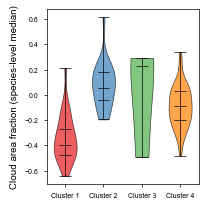

Overall Kruskal–Wallis (4 clusters): H=48.469, p=1.69e-10
Pairwise results (species-level medians):
  Cluster 1 vs Cluster 2: H=32.641, p=1.11e-08
  Cluster 1 vs Cluster 3: H=1.729, p=0.188
  Cluster 1 vs Cluster 4: H=30.593, p=3.18e-08
  Cluster 2 vs Cluster 3: H=0.399, p=0.528
  Cluster 2 vs Cluster 4: H=14.779, p=0.000121
  Cluster 3 vs Cluster 4: H=0.717, p=0.397
[Saved] Updated results for 'clt' to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/cluster_env_values_stats.json


In [34]:
# This cell performs the Kruskal–Wallis test of cloud area fraction across four clusters.
# Each species contributes one median value (calculated across all occurrence pixels).
# The violin plot shows distributions per cluster (species-level medians) WITHOUT significance annotations.
# Results (including species names and medians) are saved to a JSON file, organized by environmental variable.

import json

env_plot = 'clt'  # environmental variable: cloud area fraction

# Initialize containers
cluster_env_values = {1: [], 2: [], 3: [], 4: []}
cluster_species_names = {1: [], 2: [], 3: [], 4: []}

# ---- Collect species-level median values ----
for cluster in [1, 2, 3, 4]:
    # Get the species belonging to the current cluster
    species_list_cluster = np.array(species_list_exclude)[np.array(PU.cluster_labels) == cluster].tolist()
    
    for species in species_list_cluster:
        # Read species occurrence data
        df_species = feather.read_dataframe(PU.plot_path_df_species.replace('[SPECIES]', species))

        # Extract occurrence and corresponding environmental values
        occ_value = df_species[sorted([key for key in df_species.keys() if key.startswith('occ')])].values.flatten()
        env_value = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten()

        # Remove NaN values
        mask = ~np.isnan(occ_value) & ~np.isnan(env_value)
        occ_value = occ_value[mask]
        env_value = env_value[mask]

        # Select the environmental values where the species occurs
        i_threshold = np.where(occ_value == 1)[0]
        if i_threshold.size == 0:
            continue
        env_occ = env_value[i_threshold]

        # Compute the median environmental value for this species
        sp_median = float(np.median(env_occ))

        # Store
        cluster_env_values[cluster].append(sp_median)
        cluster_species_names[cluster].append(species)

# ---- Statistical analysis ----
H, p_kw = kruskal(cluster_env_values[1], cluster_env_values[2],
                  cluster_env_values[3], cluster_env_values[4])

pairwise_results = {}
pairs = list(itertools.combinations([1, 2, 3, 4], 2))
for (a, b) in pairs:
    stat, p = kruskal(cluster_env_values[a], cluster_env_values[b])
    pairwise_results[f'Cluster {a} vs Cluster {b}'] = (stat, p)

# ---- Visualization: Violin plot WITHOUT significance annotations ----
fig, ax = plt.subplots(figsize=mm2inch(50, 50), constrained_layout=True)

data_for_violin = [cluster_env_values[1], cluster_env_values[2],
                   cluster_env_values[3], cluster_env_values[4]]

# Define quantile lines (25% and 75%) for each cluster
quantiles_list = []
for vals in data_for_violin:
    if len(vals) >= 4:
        q = [0.25, 0.75]
    else:
        q = []
    quantiles_list.append(q)

# Violin plot of species-level medians
violin = ax.violinplot(
    data_for_violin,
    showmeans=False, showmedians=True, showextrema=True, widths=0.6,
    quantiles=quantiles_list
)

# Color customization
for i, body in enumerate(violin['bodies']):
    body.set_facecolor(PU.color_list[i % len(PU.color_list)])
    body.set_alpha(0.7)
    body.set_edgecolor('black')
    body.set_linewidth(0.5)

# Style adjustment
for key in ['cmaxes', 'cmins', 'cbars', 'cmedians', 'cquantiles']:
    if key in violin:
        c_element = violin[key]
        c_element.set_linewidth(0.5)
        c_element.set_color('black')

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'])
ax.set_ylabel('Cloud area fraction (species-level median)')

plot_output = os.path.join(PU.plot_path_suppl, f'FigS2_{env_plot}_violin_species_median_4clusters.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

print(f"Overall Kruskal–Wallis (4 clusters): H={H:.3f}, p={p_kw:.3g}")
print("Pairwise results (species-level medians):")
for k, (stat, p) in pairwise_results.items():
    print(f"  {k}: H={stat:.3f}, p={p:.3g}")

# ---- Save results to JSON ----
results_dict = {
    env_plot: {
        "data": {
            str(k): {
                "species": cluster_species_names[k],
                "medians": [float(x) for x in cluster_env_values[k]]
            } for k in [1, 2, 3, 4]
        },
        "stats": {
            "kruskal": {"H": float(H), "p": float(p_kw)},
            "pairwise": {
                f"{a}-{b}": {
                    "H": float(pairwise_results[f'Cluster {a} vs Cluster {b}'][0]),
                    "p": float(pairwise_results[f'Cluster {a} vs Cluster {b}'][1])
                } for (a, b) in pairs
            },
            "n_per_cluster": {str(k): int(len(cluster_env_values[k])) for k in [1, 2, 3, 4]}
        }
    }
}

# Output file path
json_path = os.path.join(PU.plot_path_suppl, "cluster_env_values_stats.json")

# Append or create
if os.path.exists(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        try:
            existing = json.load(f)
            if not isinstance(existing, dict):
                existing = {}
        except json.JSONDecodeError:
            existing = {}
else:
    existing = {}

# Insert or update current env_plot
existing[env_plot] = results_dict[env_plot]

# Save back
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(existing, f, indent=2, ensure_ascii=False)

print(f"[Saved] Updated results for '{env_plot}' to: {json_path}")


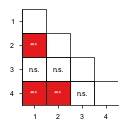

Saved pairwise significance raster to: plots/144fa175d5d1428cb9b434cd1a0024f8/FigSuppl/FigS2_clt_pairwise_significance_raster_lowertriangle.pdf


In [28]:
# ---- Additional figure: Lower-triangle raster for pairwise significance ----
# Display only the lower-left triangle (i > j) plus the diagonal boxes (i = j).
# The upper-right triangle (i < j) is hidden, and the outer frame's top/right borders are removed.

import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

n_clusters = 4
p_mat = np.full((n_clusters, n_clusters), np.nan, float)
star_mat = np.empty((n_clusters, n_clusters), dtype=object)

# Fill the lower triangle (i > j) with p-values and stars
for (a, b) in pairs:
    _, p = pairwise_results[f'Cluster {a} vs Cluster {b}']
    i, j = a - 1, b - 1
    # store in lower-left triangle
    p_mat[j, i] = p
    star_mat[j, i] = get_significance_stars(p)

# Binary significance matrix
alpha = 0.05
sig_mat = np.zeros_like(p_mat)
valid = ~np.isnan(p_mat)
sig_mat[valid] = (p_mat[valid] < alpha).astype(float)

# Mask the upper-right triangle (keep diagonal)
mask = np.triu(np.ones_like(p_mat, dtype=bool), k=1)
sig_masked = np.ma.array(sig_mat, mask=mask)

# Colormap: white for non-significant, colored for significant
sig_color = PU.color_list[0] if hasattr(PU, 'color_list') and len(PU.color_list) > 0 else '#d95f02'
cmap = ListedColormap(['#ffffff', sig_color])

fig2, ax2 = plt.subplots(figsize=mm2inch(30, 30), constrained_layout=True)

# Plot only lower triangle + diagonal
im = ax2.imshow(sig_masked, cmap=cmap, vmin=0, vmax=1)

# Axis setup
ax2.set_xticks(range(n_clusters))
ax2.set_yticks(range(n_clusters))
ax2.set_xticklabels([f'{k}' for k in range(1, n_clusters + 1)])
ax2.set_yticklabels([f'{k}' for k in range(1, n_clusters + 1)])

# Remove default grid
ax2.grid(False)

# Draw borders for lower triangle and diagonal cells only
for i in range(n_clusters):
    for j in range(n_clusters):
        if i > j or i == j:
            rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                     linewidth=0.5, edgecolor='black', facecolor='none')
            ax2.add_patch(rect)

# Annotate stars in lower triangle cells (i > j)
for i in range(n_clusters):
    for j in range(n_clusters):
        if i > j:
            label = star_mat[i, j] if star_mat[i, j] is not None else ''
            is_sig = (not np.isnan(p_mat[i, j])) and (p_mat[i, j] < alpha)
            text_color = 'white' if is_sig else 'black'
            ax2.text(j, i, label, ha='center', va='center', color=text_color)

# Remove top and right frame borders
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Optional: make the remaining left and bottom borders thinner for aesthetics
ax2.spines['left'].set_linewidth(0.5)
ax2.spines['bottom'].set_linewidth(0.5)

# Save and show
raster_output = os.path.join(PU.plot_path_suppl, f'FigS2_{env_plot}_pairwise_significance_raster_lowertriangle.pdf')
plt.savefig(raster_output, dpi=500, transparent=True)
plt.show()

print(f"Saved pairwise significance raster to: {raster_output}")


### landcoverPC1

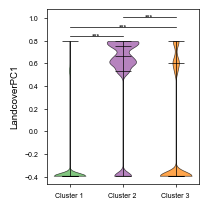

{'Cluster 1 vs Cluster 2': KruskalResult(statistic=57696.40325347088, pvalue=0.0), 'Cluster 1 vs Cluster 3': KruskalResult(statistic=11283.040652407186, pvalue=0.0), 'Cluster 2 vs Cluster 3': KruskalResult(statistic=158096.77800426504, pvalue=0.0)}


In [19]:
# Similar approach for 'landcoverPC1' across clusters, using Kruskal-Wallis.

env_plot = 'landcover_PC00'
env_min = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten().min()
env_max = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten().max()

cluster_env_values = {1: [], 2: [], 3: []}

for cluster in [1, 2, 3]:
    species_list_cluster = np.array(PU.species_list_predict)[np.array(PU.cluster_labels) == cluster].tolist()
    for species in species_list_cluster:
        df_species = feather.read_dataframe(PU.plot_path_df_species.replace('[SPECIES]', species))
        occ_value = df_species[sorted([key for key in df_species.keys() if key.startswith('occ')])].values.flatten()
        env_value = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten()
        mask = ~np.isnan(occ_value) & ~np.isnan(env_value)
        occ_value = occ_value[mask]
        env_value = env_value[mask]
        i_threshold = np.where(occ_value == 1)[0]
        env_value = env_value[i_threshold]
        cluster_env_values[cluster].extend(env_value)

pairwise_results = {
    'Cluster 1 vs Cluster 2': kruskal(cluster_env_values[1], cluster_env_values[2]),
    'Cluster 1 vs Cluster 3': kruskal(cluster_env_values[1], cluster_env_values[3]),
    'Cluster 2 vs Cluster 3': kruskal(cluster_env_values[2], cluster_env_values[3]),
}

fig, ax = plt.subplots(figsize=mm2inch(50, 50), constrained_layout=True)
violin = ax.violinplot([
    cluster_env_values[1],
    cluster_env_values[2],
    cluster_env_values[3]
], showmeans=False, showmedians=True, showextrema=True, widths=0.6,
   quantiles = [[0.25, 0.75], [0.25, 0.75], [0.25, 0.75]])

# Define violin colors.
for i, body in enumerate(violin['bodies']):
    body.set_facecolor(PU.color_list[i])
    body.set_alpha(0.7)
    body.set_edgecolor('black')
    body.set_linewidth(0.5)
for c_element in [violin['cmaxes'], violin['cmins'], violin['cbars'], violin['cmedians'], violin['cquantiles']]:
    c_element.set_linewidth(0.5)
    c_element.set_color('black')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])
ax.set_ylabel('LandcoverPC1')

y_max = max([max(cluster_env_values[i]) for i in [1, 2, 3]])
y_min = min([min(cluster_env_values[i]) for i in [1, 2, 3]])
y_step = (y_max - y_min) * 0.07

positions = [(1, 2), (1, 3), (2, 3)]
y_levels = [y_max + 0.5 * y_step, y_max + 1.5 * y_step, y_max + 2.5 * y_step]

# Add significance lines.
for i, ((pos1, pos2), y_pos) in enumerate(zip(positions, y_levels)):
    p_value = pairwise_results[list(pairwise_results.keys())[i]][1]
    significance = get_significance_stars(p_value)
    x1, x2 = pos1, pos2
    ax.plot([x1, x2], [y_pos, y_pos], color='black', linewidth=0.5)
    ax.text((x1 + x2) / 2, y_pos, significance, ha='center', va='center', fontsize=5)

plot_output = os.path.join(PU.plot_path_suppl, f'FigS2_{env_plot}_violin.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()
print(pairwise_results)

### hurs

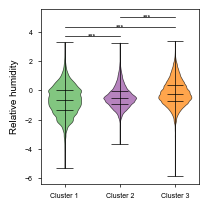

{'Cluster 1 vs Cluster 2': KruskalResult(statistic=1166.2369510830388, pvalue=1.3275131890471264e-255), 'Cluster 1 vs Cluster 3': KruskalResult(statistic=6251.49651775398, pvalue=0.0), 'Cluster 2 vs Cluster 3': KruskalResult(statistic=20353.221149592235, pvalue=0.0)}


In [20]:
# This block performs the Kruskal-Wallis test for 'hurs' among the three clusters.
# Violin plots are used to visualize group differences.

env_plot = 'hurs'
env_min = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten().min()
env_max = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten().max()

cluster_env_values = {1: [], 2: [], 3: []}

for cluster in [1, 2, 3]:
    species_list_cluster = np.array(PU.species_list_predict)[np.array(PU.cluster_labels) == cluster].tolist()
    for species in species_list_cluster:
        df_species = feather.read_dataframe(PU.plot_path_df_species.replace('[SPECIES]', species))
        occ_value = df_species[sorted([key for key in df_species.keys() if key.startswith('occ')])].values.flatten()
        env_value = PU.df_env_pca[sorted([key for key in PU.df_env_pca.keys() if key.startswith(env_plot)])].values.flatten()
        mask = ~np.isnan(occ_value) & ~np.isnan(env_value)
        occ_value = occ_value[mask]
        env_value = env_value[mask]
        i_threshold = np.where(occ_value == 1)[0]
        env_value = env_value[i_threshold]
        cluster_env_values[cluster].extend(env_value)

pairwise_results = {
    'Cluster 1 vs Cluster 2': kruskal(cluster_env_values[1], cluster_env_values[2]),
    'Cluster 1 vs Cluster 3': kruskal(cluster_env_values[1], cluster_env_values[3]),
    'Cluster 2 vs Cluster 3': kruskal(cluster_env_values[2], cluster_env_values[3]),
}

fig, ax = plt.subplots(figsize=mm2inch(50, 50), constrained_layout=True)
violin = ax.violinplot([
    cluster_env_values[1],
    cluster_env_values[2],
    cluster_env_values[3]
], showmeans=False, showmedians=True, showextrema=True, widths=0.6,
   quantiles = [[0.25, 0.75], [0.25, 0.75], [0.25, 0.75]])

# Configure violin appearance.
for i, body in enumerate(violin['bodies']):
    body.set_facecolor(PU.color_list[i])
    body.set_alpha(0.7)
    body.set_edgecolor('black')
    body.set_linewidth(0.5)
for c_element in [violin['cmaxes'], violin['cmins'], violin['cbars'], violin['cmedians'], violin['cquantiles']]:
    c_element.set_linewidth(0.5)
    c_element.set_color('black')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])
ax.set_ylabel('Relative humidity')

y_max = max([max(cluster_env_values[i]) for i in [1, 2, 3]])
y_min = min([min(cluster_env_values[i]) for i in [1, 2, 3]])
y_step = (y_max - y_min) * 0.07

positions = [(1, 2), (1, 3), (2, 3)]
y_levels = [y_max + 0.5 * y_step, y_max + 1.5 * y_step, y_max + 2.5 * y_step]

# Draw significance lines.
for i, ((pos1, pos2), y_pos) in enumerate(zip(positions, y_levels)):
    p_value = pairwise_results[list(pairwise_results.keys())[i]][1]
    significance = get_significance_stars(p_value)
    x1, x2 = pos1, pos2
    ax.plot([x1, x2], [y_pos, y_pos], color='black', linewidth=0.5)
    ax.text((x1 + x2) / 2, y_pos, significance, ha='center', va='center', fontsize=5)

plot_output = os.path.join(PU.plot_path_suppl, f'FigS2_{env_plot}_violin.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()
print(pairwise_results)

### Fig S3

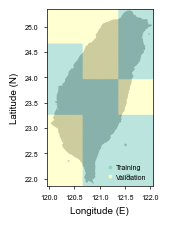

In [7]:
# This cell shows how training/validation data are divided spatially.
# A partition file is read, resized, and visualized on a map.

partition_file='./workspace/partition.txt'
train_val_partitions = np.loadtxt(partition_file, delimiter=',')
train_val_mask = cv2.resize(train_val_partitions, (
    PU.DeepSDM_conf.spatial_conf_tmp['num_of_grid_x'] * PU.DeepSDM_conf.spatial_conf_tmp['grid_size'], 
    PU.DeepSDM_conf.spatial_conf_tmp['num_of_grid_y'] * PU.DeepSDM_conf.spatial_conf_tmp['grid_size']),
    interpolation = cv2.INTER_NEAREST)

fig, ax = plt.subplots(figsize = mm2inch(40, 100), constrained_layout = True)
ax.imshow(
    np.where(PU.extent_binary == 0, np.nan, PU.extent_binary), 
    extent = PU.extent_binary_extent, cmap = ListedColormap('grey')
)
ax.imshow(
    train_val_mask, alpha = 0.6, 
    cmap = ListedColormap(['#ffffb3', '#8dd3c7']), 
    extent = PU.extent_binary_extent
)
ax.set_xlabel('Longitude (E)')
ax.set_ylabel('Latitude (N)')

validation_proxy = mlines.Line2D([], [], color='#ffffb3', marker='s', linestyle='None', markersize=2, label='Validation')
training_proxy = mlines.Line2D([], [], color='#8dd3c7', marker='s', linestyle='None', markersize=2, label='Training')

ax.legend(handles=[training_proxy, validation_proxy], loc='lower right', handletextpad=-0.2)
plot_output = os.path.join(PU.plot_path_suppl, 'Fig_S3_trainval_split.pdf')
# plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Fig S4

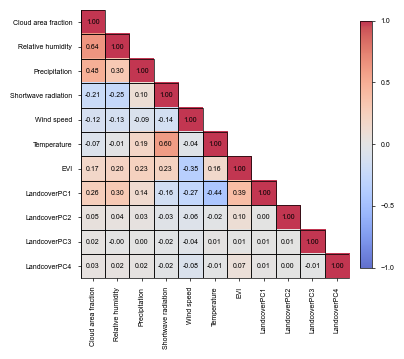

In [9]:
# This cell plots a correlation matrix (Spearman or Pearson) of environmental factors.
# It masks the upper triangle and annotates each cell with correlation values.

correlation_array = PU.df_env_corr.to_numpy()
sorted_env_factors = PU.df_env_corr.columns

mask = np.triu(np.ones_like(correlation_array, dtype=bool), k=1)
masked_corr = ma.array(correlation_array, mask=mask)
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='white')

fig, ax = plt.subplots(figsize=mm2inch(100, 100), constrained_layout=True)
cax = ax.imshow(masked_corr, cmap=cmap, interpolation='nearest', vmin=-1, vmax=1, alpha = 0.8)

cb = fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
cb.ax.tick_params()
cb.ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax.set_xticks(np.arange(len(sorted_env_factors)))
ax.set_yticks(np.arange(len(sorted_env_factors)))
ax.set_xticklabels(convert_to_env_list_detail(sorted_env_factors), rotation=90)
ax.set_yticklabels(convert_to_env_list_detail(sorted_env_factors))

# Label correlation values in the lower triangle.
for i in range(len(sorted_env_factors)):
    for j in range(len(sorted_env_factors)):
        if i >= j:
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)
            value = correlation_array[i, j]
            ax.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plot_output = os.path.join(PU.plot_path_suppl, 'FigS4_env_correlation.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

### Fig S5

In [12]:
# Load DeepSDM niche space data for all species.
species_list_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
nichespace_deepsdm_all, nichespace_deepsdm_all_nonflatten = PU.get_deepsdm_nichespace(species_exclude = species_list_exclude, suffix = 'max')

Evaluating 20 clusters...

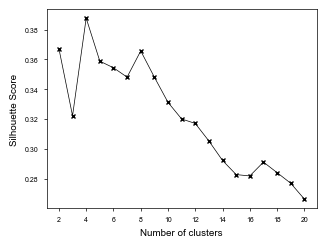

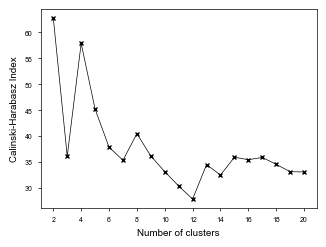

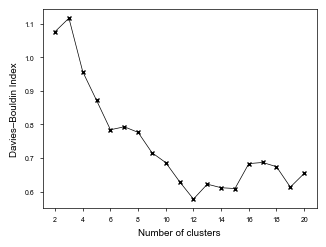

In [14]:
# This cell performs AgglomerativeClustering on niche-space data to determine how many clusters
# might be optimal. Scores such as Silhouette and Calinski-Harabasz are calculated.

# Range of clusters to evaluate
K = range(2, 21)

silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in K:
    print(f"\rEvaluating {k} clusters...", end = '')
    clustering = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='average')
    labels = clustering.fit_predict(nichespace_deepsdm_all)
    silhouette_scores.append(silhouette_score(nichespace_deepsdm_all, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(nichespace_deepsdm_all, labels))
    davies_bouldin_scores.append(davies_bouldin_score(nichespace_deepsdm_all, labels))

line_style = '-'
marker_style = 'x'
line_color = 'k'

fig, ax = plt.subplots(figsize=mm2inch(80, 60), constrained_layout=True)
ax.plot(K, silhouette_scores, linestyle=line_style, marker=marker_style, color=line_color)
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Silhouette Score')
ax.set_xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plot_output = os.path.join(PU.plot_path_suppl, 'FigS5_silhouette_score.pdf')
# plt.savefig(plot_output, dpi=500, transparent=True) 
plt.show()

fig, ax = plt.subplots(figsize=mm2inch(80, 60), constrained_layout=True)
ax.plot(K, calinski_harabasz_scores, linestyle=line_style, marker=marker_style, color=line_color)
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Calinski-Harabasz Index')
ax.set_xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plot_output = os.path.join(PU.plot_path_suppl, 'FigS5_calinski_harabasz_scores.pdf')
# plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

fig, ax = plt.subplots(figsize=mm2inch(80, 60), constrained_layout=True)
ax.plot(K, davies_bouldin_scores, linestyle=line_style, marker=marker_style, color=line_color)
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Davies–Bouldin Index')
ax.set_xticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plot_output = os.path.join(PU.plot_path_suppl, 'FigS5_davies_bouldin_scores.pdf')
# plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

### Other Figs

#### PCA result of all points

In [ ]:
x = []
y = []
for date in PU.date_list_predict:
    x.append(PU.df_env_pca[f'PC01_{date}'].values)
    y.append(PU.df_env_pca[f'PC02_{date}'].values)
x = np.concatenate(x)
y = np.concatenate(y)

env_list = list(PU.env_pca_loadings.index)

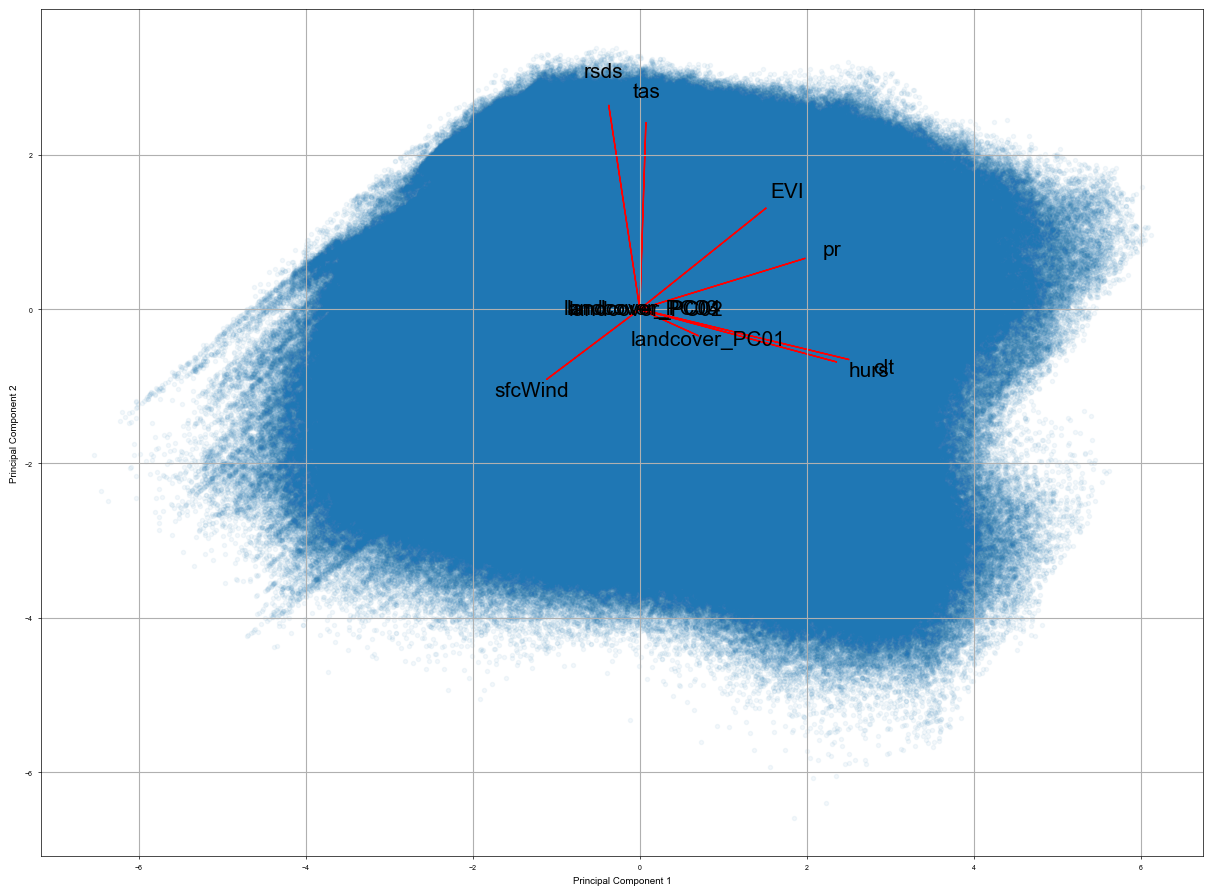

In [85]:
# Plotting the PCA results and the loadings
fig = plt.figure(figsize=(15, 11))
plt.scatter(x, y, alpha=0.05)

# Adding loading vectors
text_list = []
for i in range(PU.env_pca_loadings.shape[0]):
    plt.arrow(0, 0, PU.env_pca_loadings.loc[env_list[i], 'PC01']*3, PU.env_pca_loadings.loc[env_list[i], 'PC02']*3, color='r')
    text_list.append(plt.text(PU.env_pca_loadings.loc[env_list[i], 'PC01']*3.5, PU.env_pca_loadings.loc[env_list[i], 'PC02']*3.5, f'{env_list[i]}', color='black', ha='center', va='center', fontsize = 15))
# adjust_text(text_list)
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2')
plt.title('')
plt.grid(True)
plt.show()
# path_out = os.path.join(plot_path_nichespace, f'env_pca.png')
# fig.savefig(path_out, dpi = 100, transparent = False, facecolor='white',  bbox_inches='tight')

### Visualization of environmental factors

In [89]:
import os
import math
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# ---------- 你已經有的物件 ----------
# PU.env_info, PU.env_list, PU.date_list_predict
# 假設這三個物件已在目前的執行環境中

env_info = PU.env_info["info"]  # dict: {env: {date_str: {'tif_span_avg': path, ...}, ...}, ...}
env_list = list(PU.env_list)
date_all = [pd.to_datetime(d) for d in PU.date_list_predict]

# ---------- 參數 ----------
N_WORKERS = min(8, os.cpu_count() or 4)
OUTPUT_DIR = "viz_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 若 EVI 需縮放（例如原始值已乘 1e4），可在這裡調整比例
SCALE = {
    # "EVI": 1/10000.0,
}

def spatial_mean_from_tif(tif_path):
    """讀取單一 GeoTIFF 並回傳空間平均（忽略 nodata/NaN）。"""
    if (tif_path is None) or (not os.path.exists(tif_path)):
        return np.nan
    try:
        with rasterio.open(tif_path) as src:
            arr = src.read(1).astype("float32")
            nodata = src.nodata
            if nodata is not None:
                arr = np.where(arr == nodata, np.nan, arr)
            return float(np.nanmean(arr))
    except Exception as e:
        warnings.warn(f"Failed reading {tif_path}: {e}")
        return np.nan

# 收集 (env, date) -> tif_path
records = []
for env in env_list:
    if env not in env_info:
        continue
    for ds, meta in env_info[env].items():
        # 僅處理在 date_all 內的日期（避免混入不在預測清單的日期）
        try:
            d = pd.to_datetime(ds)
        except Exception:
            continue
        if d not in date_all:
            continue
        tif_path = meta.get("tif_span_avg")
        records.append((env, d, tif_path))

df_map = pd.DataFrame(records, columns=["env", "date", "tif"])
if df_map.empty:
    raise RuntimeError("沒有可用的 (env, date, tif) 記錄，請檢查 PU.env_info / PU.date_list_predict。")

# 並行讀取所有 tif 的空間平均
def _job(row):
    v = spatial_mean_from_tif(row["tif"])
    env = row["env"]
    if env in SCALE:
        v = v * SCALE[env]
    return (row["env"], row["date"], v)

results = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = [ex.submit(_job, row) for _, row in df_map.iterrows()]
    for fut in as_completed(futures):
        results.append(fut.result())

df_vals = pd.DataFrame(results, columns=["env", "date", "value"]).dropna(subset=["date"])
# 以完整日期範圍 reindex，缺值留 NaN
all_dates = pd.DatetimeIndex(sorted(set(date_all)))
out_tables = {}

for env in sorted(df_vals["env"].unique()):
    sub = df_vals[df_vals["env"] == env].set_index("date").sort_index()
    sub = sub.reindex(all_dates)  # 填充缺的月份（NaN）
    out_tables[env] = sub["value"]

# 合併為一張時間序列表
ts = pd.DataFrame(out_tables, index=all_dates).sort_index()
ts.to_csv(os.path.join(OUTPUT_DIR, "env_timeseries.csv"), index_label="date")

# ---------- 繪圖工具 ----------
def save_lineplot(x, y, title, xlabel, ylabel, out_path):
    plt.figure(figsize=(9, 4.8))
    plt.plot(x, y, marker="o", linewidth=1.5)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

def save_multi_year_monthly(env, df_month_year, clim, out_path):
    """
    df_month_year: index=month (1-12), columns=years, values=monthly mean
    clim: pd.Series, index=1..12
    """
    plt.figure(figsize=(9, 5.2))
    for yr in df_month_year.columns:
        plt.plot(df_month_year.index, df_month_year[yr].values, alpha=0.35, linewidth=1)
    # 多年平均加粗
    plt.plot(clim.index, clim.values, linewidth=2.5)
    plt.title(f"{env} — Monthly curves by year + climatology")
    plt.xlabel("Month")
    plt.ylabel("Spatial mean")
    plt.xticks(range(1, 13))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

# ---------- 1) 年度變化（每年一點） ----------
# 先把月度值 -> 年度平均
yearly_dir = os.path.join(OUTPUT_DIR, "annual_trends")
monthly_dir = os.path.join(OUTPUT_DIR, "monthly_by_year")
os.makedirs(yearly_dir, exist_ok=True)
os.makedirs(monthly_dir, exist_ok=True)

years = sorted(set(ts.index.year))
for env in ts.columns:
    series = ts[env]
    if series.dropna().empty:
        continue

    # 年度平均
    annual = series.groupby(series.index.year).mean()

    # 存圖（年度序列）
    save_lineplot(
        x=annual.index.values,
        y=annual.values,
        title=f"{env} — Annual mean (spatial mean of monthly rasters)",
        xlabel="Year",
        ylabel="Spatial annual mean",
        out_path=os.path.join(yearly_dir, f"annual_trends_{env}.png"),
    )

    # ---------- 2) 各年的逐月曲線 + 多年平均月均 ----------
    # 月度表（index=month 1..12, columns=years）
    monthly = series.groupby([series.index.year, series.index.month]).mean().unstack(0)
    # monthly.index: month 1..12; monthly.columns: years
    # 多年平均的 climatology
    clim = series.groupby(series.index.month).mean()

    # 如果幾乎沒有跨年變化（例如靜態層），可以選擇跳過
    maybe_static = (series.dropna().nunique() <= 2)  # 很保守的判斷
    if not maybe_static:
        # 逐年逐月曲線
        save_multi_year_monthly(
            env=env,
            df_month_year=monthly,
            clim=clim,
            out_path=os.path.join(monthly_dir, f"monthly_by_year_{env}.png"),
        )


In [5]:
import os
from collections import defaultdict
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm

# ===== 你已經有的物件 =====
env_info = PU.env_info["info"]
env_list = list(PU.env_list)
date_all = pd.to_datetime(PU.date_list_predict)

# ===== 參數 =====
OUT = "viz_maps_pdf"
os.makedirs(OUT, exist_ok=True)

# 某些層(如 EVI)需縮放 (例: /10000)
SCALE = {
    # "EVI": 1/10000.0,
}

# 是否輸出逐月異常值總覽 (年×月格)
DO_ANOMALY = False

# 百分位裁切
LOW_Q, HIGH_Q = 2, 98

# ===== 小工具 =====
def read_array(tif_path):
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        profile = src.profile
        extent = rasterio.transform.array_bounds(profile["height"], profile["width"], profile["transform"])
    return arr, profile, extent

def collect_env_date_paths(env):
    if env not in env_info:
        return []
    items, valid_dates = [], set(date_all)
    for ds, meta in env_info[env].items():
        try:
            d = pd.to_datetime(ds)
        except Exception:
            continue
        if d in valid_dates:
            p = meta.get("tif_span_avg")
            if p and os.path.exists(p):
                items.append((d, p))
    items.sort(key=lambda x: x[0])
    return items

def fixed_norm_from_arrays(arr_list, low_q=LOW_Q, high_q=HIGH_Q, center=None):
    vals = []
    for a in arr_list:
        if a is None:
            continue
        v = a[np.isfinite(a)]
        if v.size:
            vals.append(v)
    if not vals:
        return Normalize()
    v = np.concatenate(vals)
    vmin = np.percentile(v, low_q)
    vmax = np.percentile(v, high_q)
    if center is None:
        return Normalize(vmin=vmin, vmax=vmax)
    else:
        return TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)

def add_small_map(ax, arr, extent, norm=None, title=None, cmap=plt.cm.coolwarm):
    im = ax.imshow(arr, origin="upper",
                   extent=[extent[0], extent[2], extent[1], extent[3]],
                   norm=norm, cmap=cmap)
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)
    return im

def save_grid_pdf(fig, cax, norm, out_path, cmap=plt.cm.coolwarm, cbar_label=""):
    if norm is not None:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        cb = fig.colorbar(sm, cax=cax)
        if cbar_label:
            cb.set_label(cbar_label)
    fig.savefig(out_path, format="pdf", bbox_inches="tight")
    plt.close(fig)

# ===== 主流程 =====
for env in env_list:
    items = collect_env_date_paths(env)
    if not items:
        continue

    _, profile0, extent0 = read_array(items[0][1])
    scale = SCALE.get(env, 1.0)

    arrays = {}
    for d, p in items:
        arr, _, _ = read_array(p)
        arrays[d] = arr * scale

    # === 年度平均總覽 ===
    years = sorted(set([d.year for d, _ in items]))
    annual_by_year = {}
    for y in years:
        stack = [arrays[d] for d, _ in items if d.year == y]
        if stack:
            annual_by_year[y] = np.nanmean(np.stack(stack, axis=0), axis=0)
    norm_year = fixed_norm_from_arrays(list(annual_by_year.values()))

    NROWS, NCOLS = 3, 4
    per_page = NROWS * NCOLS
    pages = [years[i:i+per_page] for i in range(0, len(years), per_page)]
    for pi, yr_list in enumerate(pages, start=1):
        fig_w, fig_h = 3.6 * NCOLS, 3.0 * NROWS
        fig = plt.figure(figsize=(fig_w, fig_h))
        gs = fig.add_gridspec(nrows=NROWS, ncols=NCOLS+1,
                              width_ratios=[1]*NCOLS+[0.05],
                              wspace=0.05, hspace=0.05)

        for idx, y in enumerate(yr_list):
            r = idx // NCOLS
            c = idx % NCOLS
            ax = fig.add_subplot(gs[r, c])
            add_small_map(ax, annual_by_year[y], extent0, norm=norm_year, title=f"{y}")

        cax = fig.add_subplot(gs[:, -1])
        fig.suptitle(f"{env} — Annual Means", y=0.995, fontsize=13)
        out_pdf = os.path.join(OUT, f"{env}_annual_means{'_p'+str(pi) if len(pages)>1 else ''}.pdf")
        save_grid_pdf(fig, cax, norm_year, out_pdf)

    # === 月平均 climatology ===
    month_groups = defaultdict(list)
    for d, _ in items:
        month_groups[d.month].append(arrays[d])

    clim_by_m, clim_imgs = {}, []
    for m in range(1, 13):
        if month_groups[m]:
            clim = np.nanmean(np.stack(month_groups[m], axis=0), axis=0)
            clim_by_m[m] = clim
            clim_imgs.append(clim)
    if clim_imgs:
        norm_cli = fixed_norm_from_arrays(clim_imgs)
        NROWS, NCOLS = 3, 4
        fig_w, fig_h = 3.6 * NCOLS, 3.0 * NROWS
        fig = plt.figure(figsize=(fig_w, fig_h))
        gs = fig.add_gridspec(nrows=NROWS, ncols=NCOLS+1,
                              width_ratios=[1]*NCOLS+[0.05],
                              wspace=0.05, hspace=0.05)
        for m in range(1, 13):
            r = (m-1)//NCOLS
            c = (m-1)%NCOLS
            ax = fig.add_subplot(gs[r, c])
            if m in clim_by_m:
                add_small_map(ax, clim_by_m[m], extent0, norm=norm_cli, title=f"Month {m:02d}")
            else:
                ax.axis("off")
        cax = fig.add_subplot(gs[:, -1])
        fig.suptitle(f"{env} — Monthly Climatology", y=0.995, fontsize=13)
        out_pdf = os.path.join(OUT, f"{env}_monthly_climatology.pdf")
        save_grid_pdf(fig, cax, norm_cli, out_pdf)


/tmp/ipykernel_261361/2821755330.py:112: RuntimeWarning: Mean of empty slice
  annual_by_year[y] = np.nanmean(np.stack(stack, axis=0), axis=0)
/tmp/ipykernel_261361/2821755330.py:144: RuntimeWarning: Mean of empty slice
  clim = np.nanmean(np.stack(month_groups[m], axis=0), axis=0)


In [8]:
import os
from collections import defaultdict, OrderedDict
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import imageio.v3 as iio

# ===== 你已經有的物件 =====
env_info = PU.env_info["info"]
env_list = list(PU.env_list)
date_all = pd.to_datetime(PU.date_list_predict)

# ===== 參數 =====
OUT = "viz_gif_all"
os.makedirs(OUT, exist_ok=True)

# 依變數調整縮放（例如 EVI /10000）
SCALE = {
    # "EVI": 1/10000.0,
}

# 固定色階的分位數（抑制極端值影響）
LOW_Q, HIGH_Q = 2, 98

# 各類 GIF 的播放速度（毫秒/幀）
FRAME_MS_CLIMATOLOGY = 500   # 12 幀
FRAME_MS_ANNUAL      = 400   # 年數通常比月少
FRAME_MS_ORIGINAL    = 180   # 原始月序列很多，播快一點

# 是否來回（boomerang）播放
BOOMERANG_CLIM = False
BOOMERANG_ANNUAL = False
BOOMERANG_ORIGINAL = False

# 單幀圖尺寸（英吋）
FIGSIZE = (6, 6)

# ===== 小工具 =====
def read_array(tif_path):
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        profile = src.profile
        extent = rasterio.transform.array_bounds(
            profile["height"], profile["width"], profile["transform"]
        )
    return arr, profile, extent

def collect_env_date_paths(env):
    """回傳該 env 在 date_all 範圍內實際存在的 (date, tif_path)（時間排序）"""
    if env not in env_info:
        return []
    items, valid_dates = [], set(date_all)
    for ds, meta in env_info[env].items():
        try:
            d = pd.to_datetime(ds)
        except Exception:
            continue
        if d in valid_dates:
            p = meta.get("tif_span_avg")
            if p and os.path.exists(p):
                items.append((d, p))
    items.sort(key=lambda x: x[0])
    return items

def fixed_norm_from_arrays(arr_list, low_q=LOW_Q, high_q=HIGH_Q):
    vals = []
    for a in arr_list:
        if a is None:
            continue
        v = a[np.isfinite(a)]
        if v.size:
            vals.append(v)
    if not vals:
        return Normalize(vmin=0.0, vmax=1.0)
    v = np.concatenate(vals)
    vmin = np.percentile(v, low_q)
    vmax = np.percentile(v, high_q)
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin == vmax):
        eps = 1e-6
        return Normalize(vmin=vmin - eps, vmax=vmax + eps)
    return Normalize(vmin=vmin, vmax=vmax)

def render_frame(arr, extent, title=None, norm=None):
    """回傳 (H,W,3) 的 uint8 影像幀；用 buffer_rgba 取得圖像避免相容性問題。"""
    fig = plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    im = ax.imshow(
        arr, origin="upper",
        extent=[extent[0], extent[2], extent[1], extent[3]],
        cmap=plt.cm.coolwarm, norm=norm
    )
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=12)

    # 右側色條
    cax = fig.add_axes([0.90, 0.12, 0.03, 0.76])
    cb = fig.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=8)

    # 用 margins 而非 tight_layout，避免 add_axes 衝突
    fig.subplots_adjust(left=0.06, right=0.88, top=0.90, bottom=0.08)

    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    frame = buf.reshape((h, w, 4))[..., :3].copy()
    plt.close(fig)
    return frame

# ===== 主流程 =====
for env in env_list:
    items = collect_env_date_paths(env)
    if not items:
        continue
    scale = SCALE.get(env, 1.0)

    # 參考 extent
    _, _, extent0 = read_array(items[0][1])

    # 讀入所有原始月度影像（一次 I/O，後面重用）
    arrays_by_date = OrderedDict()
    for d, p in items:
        arr, _, _ = read_array(p)
        arrays_by_date[d] = arr * scale

    # ---------- 1) Monthly Climatology GIF ----------
    # 跨年按月份聚合
    month_groups = defaultdict(list)
    for d, arr in arrays_by_date.items():
        month_groups[d.month].append(arr)

    months_present = [m for m in range(1, 13) if len(month_groups[m]) > 0]
    if months_present:
        clim_by_m = {}
        for m in months_present:
            stack = np.stack(month_groups[m], axis=0)   # [N, H, W]
            clim_by_m[m] = np.nanmean(stack, axis=0)

        # 固定色階：以所有 climatology 月影像
        norm_cli = fixed_norm_from_arrays([clim_by_m[m] for m in months_present])

        seq = months_present.copy()
        if BOOMERANG_CLIM and len(seq) > 1:
            seq = seq + seq[-2:0:-1]

        frames = []
        for m in seq:
            title = f"{env} — Monthly Climatology (Month {m:02d})"
            frames.append(render_frame(clim_by_m[m], extent0, title=title, norm=norm_cli))

        out_path = os.path.join(OUT, f"{env}_climatology.gif")
        iio.imwrite(out_path, frames, format="GIF", loop=0, duration=FRAME_MS_CLIMATOLOGY)

    # ---------- 2) Annual Mean GIF ----------
    # 逐年平均
    years = sorted(set(d.year for d in arrays_by_date.keys()))
    annual_by_year = OrderedDict()
    for y in years:
        stack = [arr for d, arr in arrays_by_date.items() if d.year == y]
        if stack:
            annual_by_year[y] = np.nanmean(np.stack(stack, axis=0), axis=0)

    if len(annual_by_year) > 0:
        norm_year = fixed_norm_from_arrays(list(annual_by_year.values()))

        seq_years = years.copy()
        if BOOMERANG_ANNUAL and len(seq_years) > 1:
            seq_years = seq_years + seq_years[-2:0:-1]

        frames = []
        for y in seq_years:
            if y not in annual_by_year:
                continue
            title = f"{env} — Annual Mean ({y})"
            frames.append(render_frame(annual_by_year[y], extent0, title=title, norm=norm_year))

        out_path = os.path.join(OUT, f"{env}_annual_mean.gif")
        iio.imwrite(out_path, frames, format="GIF", loop=0, duration=FRAME_MS_ANNUAL)

    # ---------- 3) Original Timeline GIF ----------
    # 依原始時間順序逐月播放（所有原始檔）
    if len(arrays_by_date) > 0:
        # 固定色階：用「全部原始月度影像」共同決定
        norm_orig = fixed_norm_from_arrays(list(arrays_by_date.values()))

        seq_dates = list(arrays_by_date.keys())
        if BOOMERANG_ORIGINAL and len(seq_dates) > 1:
            seq_dates = seq_dates + seq_dates[-2:0:-1]

        frames = []
        for d in seq_dates:
            title = f"{env} — Original {d.strftime('%Y-%m')}"
            frames.append(render_frame(arrays_by_date[d], extent0, title=title, norm=norm_orig))

        out_path = os.path.join(OUT, f"{env}_original_timeline.gif")
        iio.imwrite(out_path, frames, format="GIF", loop=0, duration=FRAME_MS_ORIGINAL)

print(f"All GIFs exported to: {OUT}")


/tmp/ipykernel_261361/156778690.py:143: RuntimeWarning: Mean of empty slice
  clim_by_m[m] = np.nanmean(stack, axis=0)
/tmp/ipykernel_261361/156778690.py:167: RuntimeWarning: Mean of empty slice
  annual_by_year[y] = np.nanmean(np.stack(stack, axis=0), axis=0)


All GIFs exported to: viz_gif_all


### Test the cph of BBS data

In [44]:
bbs_data = pd.read_csv('./raw/0009715-250914085247600.csv', 
                        sep = '\t', 
                        usecols = [
                            'species',
                            'decimalLatitude',
                            'decimalLongitude',
                            'day',
                            'month',
                            'year', 
                            'coordinateUncertaintyInMeters', 
                            'coordinatePrecision', 
                            'individualCount'],
                       nrows=None,
                       quoting=csv.QUOTE_NONE
                              )

In [52]:
len(bbs_data)

513418

In [53]:
bbs_data.dropna()

,species,individualCount,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,coordinatePrecision,day,month,year
0,Psilopogon nuchalis,1.0,25.21615,121.53783,100.0,0.00001,22,3,2009
1,Pycnonotus sinensis,1.0,25.21835,121.53670,100.0,0.00001,16,4,2009
2,Bubulcus ibis,1.0,25.21835,121.53670,100.0,0.00001,25,5,2009
3,Pycnonotus sinensis,2.0,25.11127,121.81630,100.0,0.00001,10,3,2009
4,Stachyridopsis ruficeps,2.0,25.11127,121.81630,100.0,0.00001,26,4,2009
...,...,...,...,...,...,...,...,...,...
513413,Spilopelia chinensis,2.0,24.47173,118.29273,100.0,0.00001,5,5,2018
513414,Centropus sinensis,1.0,24.47696,118.29480,100.0,0.00001,5,5,2018
513415,Anas zonorhyncha,1.0,24.47996,118.29839,100.0,0.00001,5,5,2018
513416,Pycnonotus sinensis,1.0,24.47724,118.30382,100.0,0.00001,5,5,2018


In [64]:
PU.df_env_pca

,clt_2001-01-01,hurs_2001-01-01,pr_2001-01-01,rsds_2001-01-01,sfcWind_2001-01-01,tas_2001-01-01,EVI_2001-01-01,landcover_PC01_2001-01-01,landcover_PC02_2001-01-01,landcover_PC03_2001-01-01,...,PC02_2018-12-01,PC03_2018-12-01,PC04_2018-12-01,PC05_2018-12-01,PC06_2018-12-01,PC07_2018-12-01,PC08_2018-12-01,PC09_2018-12-01,PC10_2018-12-01,PC11_2018-12-01
0,0.367365,-0.800839,-0.061936,-1.541649,3.518790,-0.464742,-3.439066,-0.513615,-0.055758,0.117469,...,-2.990469,3.694324,1.013554,1.268205,-0.151421,1.228015,0.475493,0.092744,0.099081,0.194433
1,0.403976,-0.692685,-0.022182,-1.582127,2.507349,-0.464470,-2.186827,-0.508090,-0.053766,0.111924,...,-2.935811,3.182471,0.267972,0.301115,-0.245175,1.083879,0.508215,0.111043,0.075178,0.177994
2,0.413188,-0.673014,-0.013109,-1.589111,2.668263,-0.464198,-2.342106,-0.513615,-0.055758,0.117469,...,-2.889345,3.190203,0.458358,0.558053,-0.272666,1.124526,0.462780,0.088758,0.086017,0.180247
3,0.333355,-0.843989,-0.071995,-1.525133,3.175632,-0.480600,-3.753196,-0.514862,-0.056222,0.118779,...,-3.460423,4.192143,0.103635,0.052768,0.089812,0.895857,0.748542,0.225790,0.078752,0.236446
4,0.373756,-0.681461,-0.032911,-1.584055,2.239499,-0.496725,-1.884833,-0.594043,-0.103504,0.306615,...,-2.227114,2.078086,0.993738,1.325895,-0.654332,1.511340,0.080902,-0.147631,0.264494,0.769996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46024,-1.221381,-1.333115,-0.756276,-0.377370,3.858024,0.273632,0.109385,-0.594043,-0.103504,0.306615,...,-1.383778,3.576584,1.376790,2.224611,-0.216329,0.073990,0.339571,0.043971,0.314856,0.871032
46025,-1.205624,-1.356789,-0.753955,-0.441977,4.945189,0.291116,-0.200789,-0.594043,-0.103504,0.306615,...,-1.747652,4.495981,1.886938,2.908577,-0.066511,0.062563,0.414707,0.079439,0.328837,0.899810
46026,-1.195153,-1.372181,-0.756271,-0.393028,3.888972,0.290579,-2.189326,-0.499705,-0.050928,0.104247,...,-1.216573,3.338238,1.698627,2.615666,-0.281313,0.183908,0.338988,0.090409,0.139446,0.193537
46027,-1.179116,-1.520149,-0.759500,-0.377389,3.135349,0.322290,-4.349604,-0.537892,-0.065891,0.147879,...,-0.990109,2.760207,1.354835,2.034608,-0.397029,0.280300,0.310646,0.056714,0.167390,0.231218


In [55]:
PU.extent_binary_extent

[119.95416666665, 122.04583332495, 21.85416668065, 25.34583333335]

In [65]:
PU.height

420

In [66]:
PU.width

252

In [58]:
PU.transform

Affine(0.0083333333, 0.0, 119.95,
       0.0, -0.0083333333, 25.35)

In [67]:
import numpy as np
import pandas as pd
import re
from affine import Affine

def attach_pc(bbs_data, PU, pcs_to_keep=None):
    """
    將 bbs_data 的經緯度 + 年月，對齊到 PU.df_env_pca 的 PC 軸數值
    - 空間依據 PU.transform + PU.extent_binary
    - 時間忽略日，只對齊到每月一號 (YYYY-MM-01)
    - pcs_to_keep: 例如 ["PC01","PC02"]；若為 None 則自動偵測所有 PC 軸
    回傳：新增欄位 pu_row, month_str，以及指定的 PC 欄位（不在 mask 或無該月則為 NaN）
    """
    transform: Affine = PU.transform
    height, width = PU.height, PU.width

    # ---------- 1) 經緯度 -> raster 索引 ----------
    def lonlat_to_rowcol(lon, lat, transform):
        col, row = (~transform) * (lon, lat)     # (~Affine) * (x,y) -> (col,row)
        return int(np.floor(row)), int(np.floor(col))

    # 建立「2D -> 攤平(只保留==1)」的索引映射 (C-order)
    flat_idx_map = np.full(height * width, -1, dtype=np.int64)
    mask_flat = PU.extent_binary.reshape(-1).astype(bool)
    flat_idx_map[mask_flat] = np.arange(mask_flat.sum(), dtype=np.int64)

    def point_to_pu_row(lon, lat):
        r, c = lonlat_to_rowcol(lon, lat, transform)
        if r < 0 or r >= height or c < 0 or c >= width:
            return -1
        lin = r * width + c
        return int(flat_idx_map[lin])

    bbs = bbs_data.copy()
    bbs["pu_row"] = [
        point_to_pu_row(lon, lat)
        for lon, lat in zip(bbs["decimalLongitude"], bbs["decimalLatitude"])
    ]

    # ---------- 2) 忽略日，只保留月份 ----------
    bbs["month_str"] = pd.to_datetime(dict(
        year=bbs["year"], month=bbs["month"], day=1
    )).dt.strftime("%Y-%m-%d")

    # ---------- 3) 建立月份 -> PC欄位 對應表 ----------
    col_re = re.compile(r"^(PC\d{2})_(\d{4}-\d{2}-\d{2})$")
    date_to_cols = {}
    all_pcs = set()

    for c in PU.df_env_pca.columns:
        m = col_re.match(c)
        if m:
            pc_name, date_str = m.group(1), m.group(2)
            date_to_cols.setdefault(date_str, []).append(c)
            all_pcs.add(pc_name)

    # 決定要保留哪些 PC 軸
    if pcs_to_keep is None:
        pcs = sorted(all_pcs)                     # 例如 ['PC01',...'PC08']
    else:
        pcs = [p for p in pcs_to_keep if p in all_pcs]

    # ---------- 4) 預先建立 PC 欄位 ----------
    for pc in pcs:
        bbs[pc] = np.nan

    # ---------- 5) 逐月填值（僅針對 pcs_to_keep） ----------
    # 為每個月份把對應欄位過濾成指定 PC 軸，再依 pu_row 抽值
    for month_str, idx in bbs.groupby("month_str").groups.items():
        month_cols_all = date_to_cols.get(month_str, [])
        if not month_cols_all:
            continue

        # 僅留下指定 PC 的欄位，並依 PC 序號排序
        month_cols = []
        for pc in pcs:
            # 找到這個月、且對應 pc 的欄位（理論應該只會有一個）
            matched = [c for c in month_cols_all if c.startswith(f"{pc}_")]
            if matched:
                month_cols.append(matched[0])

        if not month_cols:
            continue

        pu_rows = bbs.loc[idx, "pu_row"].to_numpy()
        valid = pu_rows >= 0
        if not valid.any():
            continue

        block = PU.df_env_pca.iloc[pu_rows[valid]][month_cols].to_numpy()

        # 指定回各 PC 欄位
        for j, col in enumerate(month_cols):
            pc_name = re.match(r"^(PC\d{2})_", col).group(1)
            bbs.loc[idx[valid], pc_name] = block[:, j]

    return bbs


In [71]:
# bbs_data: 含 decimalLatitude, decimalLongitude, year, month, day
# PU: 物件內含 df_env_pca, transform, height, width
# PU.extent_binary: numpy.ndarray, shape == (PU.height, PU.width)
bbs_data = bbs_data.dropna().reset_index(drop = True)
bbs_with_pc = attach_pc(bbs_data, PU, pcs_to_keep=["PC01","PC02"])
# bbs_with_pc 會多出欄位：pu_row, month_str, PC01, PC02

In [ ]:
bbs_with_pc = bbs_with_pc.dropna().reset_index(drop = True)
bbs_with_pc.species = [i.replace(' ', '_') for i in bbs_with_pc.species.values]

Sinosuthora_webbiana 紀錄數 = 410（其中 abundance>0 的有 410 筆）
Spearman ρ = -0.088, p = 0.0742
線性模型 log1p(abundance) ~ distance：slope = -0.0586, t = -1.53, p = 0.126
Center–Periphery Hypothesis 判讀：方向相符但不顯著（部分支持）


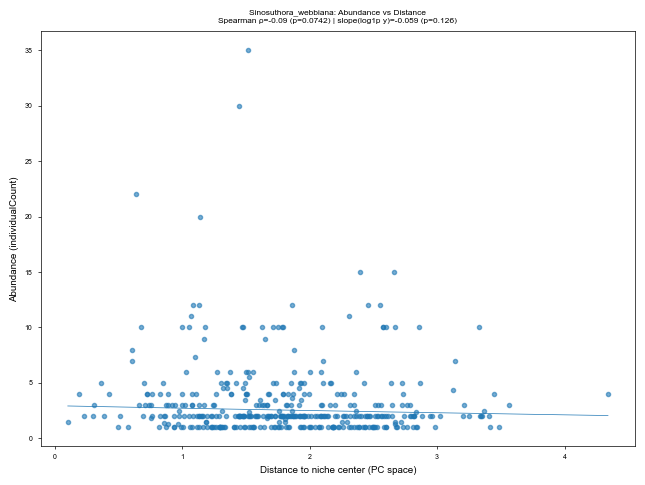

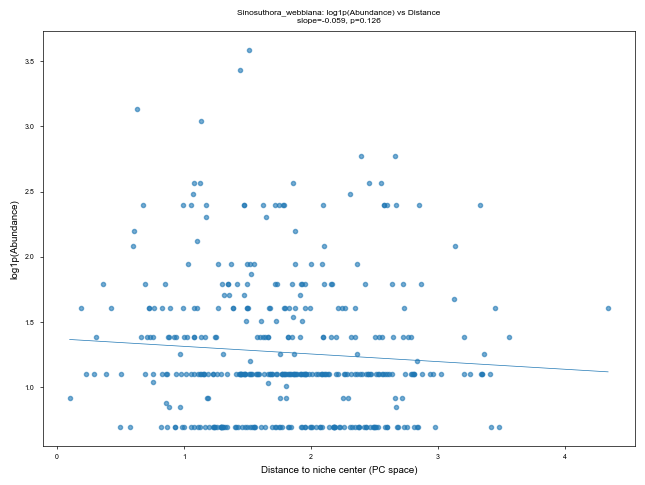

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === 準備資料 ===
# 1) niche 中心座標（每物種一列，含 PC01、PC02）
#    路徑若不同，改這行
center_path = Path("./plots/144fa175d5d1428cb9b434cd1a0024f8/Fig5_nichespace_clustering/nichespecies_center_coordinate.csv")
centers = pd.read_csv(center_path)

# 2) 從 bbs_with_pc 取出目標物種（此 df 應已包含 PC01、PC02 與 abundance 欄位）
species_name = "Sinosuthora_webbiana"
df = bbs_with_pc.loc[bbs_with_pc["species"] == species_name].copy()
df = df.groupby(['pu_row', 'month_str']).mean('individualCount')
# 檢查必要欄位
need_cols = {"PC01", "PC02", "individualCount"}
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"bbs_with_pc 缺少欄位：{missing}")

# 讀取該物種的 niche 中心
c_row = centers.loc[centers.iloc[:,0].isin([species_name])]
if c_row.empty:
    raise ValueError(f"在 nichespecies_center_coordinate.csv 找不到 {species_name} 的中心座標")
# 假設 CSV 第一欄是物種名，其餘欄含 'PC01','PC02'
# 若你的 CSV 欄名不是 PC01/PC02，而是其他名稱，請在這裡調整欄名
c_PC01 = float(c_row["PC01"].iloc[0])
c_PC02 = float(c_row["PC02"].iloc[0])

# === 計算距離 ===
df["distance_to_center"] = np.hypot(df["PC01"] - c_PC01, df["PC02"] - c_PC02)

# === 基本統計 ===
n = len(df)
n_pos = (df["individualCount"] > 0).sum()
print(f"{species_name} 紀錄數 = {n}（其中 abundance>0 的有 {n_pos} 筆）")

# Spearman 相關（距離 vs abundance）
try:
    from scipy.stats import spearmanr
    rho, p_s = spearmanr(df["distance_to_center"], df["individualCount"])
    print(f"Spearman ρ = {rho:.3f}, p = {p_s:.3g}")
except Exception as e:
    print("無法執行 scipy 的 Spearman 相關，將略過。錯誤：", e)
    rho = np.nan
    p_s = np.nan

# 線性模型：log1p(abundance) ~ distance
y = np.log1p(df["individualCount"].values.astype(float))
X = np.c_[np.ones(len(df)), df["distance_to_center"].values.astype(float)]
# OLS 解析解
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
intercept, slope = beta
# 殘差與標準誤估計
y_hat = X @ beta
resid = y - y_hat
sigma2 = (resid**2).sum() / (len(df) - X.shape[1])
# 標準誤與 t 檢定（對斜率）
XtX_inv = np.linalg.inv(X.T @ X)
se_slope = np.sqrt(sigma2 * XtX_inv[1,1])
t_stat = slope / (se_slope + 1e-12)

try:
    from scipy.stats import t
    dfree = len(df) - X.shape[1]
    p_lin = 2 * (1 - t.cdf(np.abs(t_stat), df=dfree))
except Exception:
    # 粗略以常態近似
    from math import erf, sqrt
    p_lin = 2 * (1 - 0.5*(1+erf(np.abs(t_stat)/np.sqrt(2))))

print(f"線性模型 log1p(abundance) ~ distance：slope = {slope:.4f}, t = {t_stat:.2f}, p = {p_lin:.3g}")

# --- 結論（是否支持 CPH）---
direction_ok = slope < 0
sig_ok = p_lin < 0.05
if direction_ok and sig_ok:
    verdict = "支持"
elif direction_ok and not sig_ok:
    verdict = "方向相符但不顯著（部分支持）"
else:
    verdict = "不支持（或相反方向）"
print(f"Center–Periphery Hypothesis 判讀：{verdict}")

# === 視覺化 ===
# 1) abundance vs distance（原始尺度）
plt.figure()
plt.scatter(df["distance_to_center"], df["individualCount"], alpha=0.6)
# 回歸線（用 OLS 的預測；需把 y 轉回原尺度）
x_line = np.linspace(df["distance_to_center"].min(), df["distance_to_center"].max(), 200)
y_line = np.exp(intercept + slope * x_line) - 1.0  # 反轉 log1p
plt.plot(x_line, y_line)
plt.xlabel("Distance to niche center (PC space)")
plt.ylabel("Abundance (individualCount)")
plt.title(f"{species_name}: Abundance vs Distance\n"
          f"Spearman ρ={rho:.2f} (p={p_s:.3g}) | slope(log1p y)={slope:.3f} (p={p_lin:.3g})")
plt.tight_layout()
plt.show()

# 2) log1p(abundance) vs distance（線性關係更清楚）
plt.figure()
plt.scatter(df["distance_to_center"], np.log1p(df["individualCount"]), alpha=0.6)
plt.plot(x_line, intercept + slope * x_line)
plt.xlabel("Distance to niche center (PC space)")
plt.ylabel("log1p(Abundance)")
plt.title(f"{species_name}: log1p(Abundance) vs Distance\nslope={slope:.3f}, p={p_lin:.3g}")
plt.tight_layout()
plt.show()
